<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/34_silhouette_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
X, y = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

In [3]:
scores = []

In [4]:
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(
        X,
        labels
    )

    scores.append(score)

In [5]:
results = pd.DataFrame({
    "K": range(2,11),
    "Silhouette Score": scores
})

results

,K,Silhouette Score
0,2,0.590218
1,3,0.756911
2,4,0.791583
3,5,0.664187
4,6,0.532952
5,7,0.426312
6,8,0.335211
7,9,0.345426
8,10,0.361733


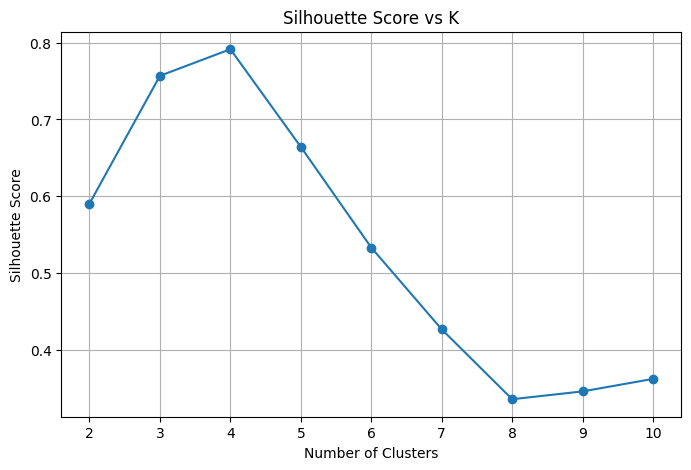

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Score vs K"
)

plt.grid()

plt.show()

In [7]:
best_k = results.loc[
    results["Silhouette Score"].idxmax(),
    "K"
]

print(
    "Best K:",
    best_k
)

Best K: 4


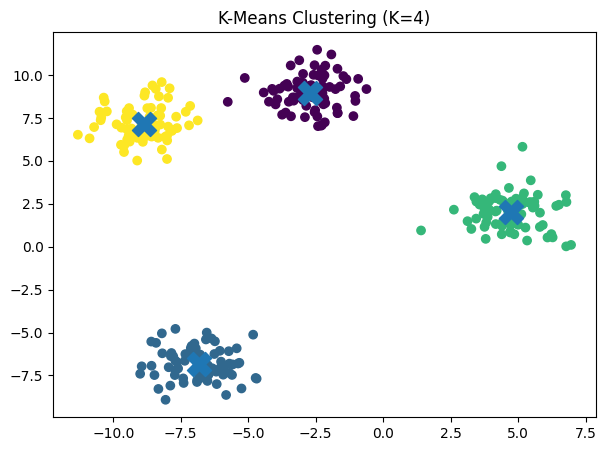

In [8]:
kmeans = KMeans(
    n_clusters=int(best_k),
    random_state=42
)

clusters = kmeans.fit_predict(X)

plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.title(
    f"K-Means Clustering (K={best_k})"
)

plt.show()

## Conclusion

This notebook evaluated clustering quality using the Silhouette Score.

Observations:
- Higher silhouette scores indicate better cluster separation.
- Different values of K produce different clustering quality.
- Silhouette Score provides a quantitative way to select the number of clusters.
- It complements the Elbow Method for cluster evaluation.